In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("usa_marketing_dataset.csv")
df

,CustomerID,FullName,Age,Gender,Email,Phone,Country,State,City,ZipCode,...,Revenue,ProductCategory,ProductPrice,DiscountApplied,PaymentMethod,OrderStatus,CustomerSatisfactionScore,SupportTickets,ReturnFlag,IsActiveCustomer
0,US43227,Olivia Garcia,49,NaN,user930@gmail.com,1.498757e+10,USA,Illinois,New York,49576.0,...,279.01,Sports,304.63,10.0,PayPal,Completed,2.0,3,0,0
1,US74388,Isabella Miller,NaN,Other,user1162@gmail.com,1.839198e+10,USA,Texas,Miami,NaN,...,1174.11,NaN,956.63,30.0,PayPal,Returned,3.0,6,1,1
2,US11385,James Miller,Unknown,NaN,user7412@gmail.com,1.640819e+10,USA,NaN,Los Angeles,48282.0,...,NaN,Beauty,941.40,0.0,NaN,NaN,4.0,7,1,0
3,US15659,Noah Miller,58,NaN,invalid_email,1.335483e+10,USA,NaN,NaN,89333.0,...,3411.56,Electronics,249.79,10.0,PayPal,Pending,3.0,1,1,0
4,US36522,Noah Johnson,24,Male,user140@gmail.com,1.679216e+10,USA,California,Los Angeles,83301.0,...,1774.74,Clothing,376.47,0.0,Credit Card,Pending,NaN,2,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3195,US98030,Ava Rodriguez,Unknown,Other,user5193@gmail.com,1.418119e+10,USA,Illinois,Los Angeles,32003.0,...,2634.97,Home,535.78,30.0,NaN,Pending,1.0,3,1,0
3196,US63369,Ava Smith,Unknown,NaN,user1905@gmail.com,NaN,USA,Florida,NaN,41608.0,...,2347.16,NaN,663.77,NaN,Credit Card,Returned,1.0,4,0,0
3197,US50739,John Davis,Unknown,Male,user7649@gmail.com,1.653402e+10,USA,California,Miami,86789.0,...,136.37,Sports,606.69,20.0,Credit Card,Returned,NaN,2,0,0
3198,US12510,Liam Martinez,68,NaN,user4088@gmail.com,1.662918e+10,USA,Florida,Chicago,NaN,...,2786.10,Beauty,880.90,20.0,NaN,Completed,5.0,10,1,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3200 entries, 0 to 3199
Data columns (total 31 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   CustomerID                 3200 non-null   object 
 1   FullName                   3070 non-null   object 
 2   Age                        2113 non-null   object 
 3   Gender                     1898 non-null   object 
 4   Email                      3200 non-null   object 
 5   Phone                      2882 non-null   float64
 6   Country                    3200 non-null   object 
 7   State                      2684 non-null   object 
 8   City                       2680 non-null   object 
 9   ZipCode                    1636 non-null   float64
 10  SignupDate                 3200 non-null   object 
 11  LastLoginDate              3200 non-null   object 
 12  CampaignName               2526 non-null   object 
 13  Channel                    2590 non-null   objec

In [4]:
df.isnull().sum()

CustomerID                      0
FullName                      130
Age                          1087
Gender                       1302
Email                           0
Phone                         318
Country                         0
State                         516
City                          520
ZipCode                      1564
SignupDate                      0
LastLoginDate                   0
CampaignName                  674
Channel                       610
AdSpend                       325
Clicks                       1588
Impressions                     0
CTR                             0
ConversionRate                  0
LeadsGenerated                  0
Conversions                     0
Revenue                       318
ProductCategory               559
ProductPrice                    0
DiscountApplied               645
PaymentMethod                1260
OrderStatus                   642
CustomerSatisfactionScore     502
SupportTickets                  0
ReturnFlag    

In [5]:
df.dtypes

CustomerID                    object
FullName                      object
Age                           object
Gender                        object
Email                         object
Phone                        float64
Country                       object
State                         object
City                          object
ZipCode                      float64
SignupDate                    object
LastLoginDate                 object
CampaignName                  object
Channel                       object
AdSpend                      float64
Clicks                       float64
Impressions                    int64
CTR                          float64
ConversionRate               float64
LeadsGenerated                 int64
Conversions                    int64
Revenue                      float64
ProductCategory               object
ProductPrice                 float64
DiscountApplied              float64
PaymentMethod                 object
OrderStatus                   object
C

In [6]:
df['Age'] = df['Age'].replace('Unknown', np.nan)
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')

df['Age'] = df['Age'].fillna(df['Age'].median()).astype(int)

In [7]:
df.head()

,CustomerID,FullName,Age,Gender,Email,Phone,Country,State,City,ZipCode,...,Revenue,ProductCategory,ProductPrice,DiscountApplied,PaymentMethod,OrderStatus,CustomerSatisfactionScore,SupportTickets,ReturnFlag,IsActiveCustomer
0,US43227,Olivia Garcia,49,NaN,user930@gmail.com,1.498757e+10,USA,Illinois,New York,49576.0,...,279.01,Sports,304.63,10.0,PayPal,Completed,2.0,3,0,0
1,US74388,Isabella Miller,44,Other,user1162@gmail.com,1.839198e+10,USA,Texas,Miami,NaN,...,1174.11,NaN,956.63,30.0,PayPal,Returned,3.0,6,1,1
2,US11385,James Miller,44,NaN,user7412@gmail.com,1.640819e+10,USA,NaN,Los Angeles,48282.0,...,NaN,Beauty,941.40,0.0,NaN,NaN,4.0,7,1,0
3,US15659,Noah Miller,58,NaN,invalid_email,1.335483e+10,USA,NaN,NaN,89333.0,...,3411.56,Electronics,249.79,10.0,PayPal,Pending,3.0,1,1,0
4,US36522,Noah Johnson,24,Male,user140@gmail.com,1.679216e+10,USA,California,Los Angeles,83301.0,...,1774.74,Clothing,376.47,0.0,Credit Card,Pending,NaN,2,1,1


In [8]:

df['Phone'] = df['Phone'].fillna('Unknown').astype(str)

# ZipCode
df['ZipCode'] = df['ZipCode'].fillna('Unknown').astype(str)

# Dates
df['SignupDate'] = pd.to_datetime(df['SignupDate'], errors='coerce')
df['LastLoginDate'] = pd.to_datetime(df['LastLoginDate'], errors='coerce')

In [9]:
df.head(9)

,CustomerID,FullName,Age,Gender,Email,Phone,Country,State,City,ZipCode,...,Revenue,ProductCategory,ProductPrice,DiscountApplied,PaymentMethod,OrderStatus,CustomerSatisfactionScore,SupportTickets,ReturnFlag,IsActiveCustomer
0,US43227,Olivia Garcia,49,NaN,user930@gmail.com,14987565811.0,USA,Illinois,New York,49576.0,...,279.01,Sports,304.63,10.0,PayPal,Completed,2.0,3,0,0
1,US74388,Isabella Miller,44,Other,user1162@gmail.com,18391982513.0,USA,Texas,Miami,Unknown,...,1174.11,NaN,956.63,30.0,PayPal,Returned,3.0,6,1,1
2,US11385,James Miller,44,NaN,user7412@gmail.com,16408189242.0,USA,NaN,Los Angeles,48282.0,...,NaN,Beauty,941.40,0.0,NaN,NaN,4.0,7,1,0
3,US15659,Noah Miller,58,NaN,invalid_email,13354831949.0,USA,NaN,NaN,89333.0,...,3411.56,Electronics,249.79,10.0,PayPal,Pending,3.0,1,1,0
4,US36522,Noah Johnson,24,Male,user140@gmail.com,16792159897.0,USA,California,Los Angeles,83301.0,...,1774.74,Clothing,376.47,0.0,Credit Card,Pending,NaN,2,1,1
5,US28471,Emma Johnson,44,NaN,user8479@gmail.com,Unknown,USA,New York,Chicago,97005.0,...,2032.91,Electronics,232.95,10.0,PayPal,Completed,4.0,0,0,0
6,US66116,Isabella Williams,44,Female,user4321@gmail.com,13819683669.0,USA,Florida,Los Angeles,67472.0,...,3713.43,Beauty,858.75,20.0,Debit Card,Completed,1.0,5,0,1
7,US93794,Emma Martinez,27,NaN,user6271@gmail.com,12055750853.0,USA,California,NaN,Unknown,...,1380.77,Clothing,285.50,30.0,PayPal,Returned,NaN,5,1,0
8,US63182,William Miller,44,Male,user8629@gmail.com,19155497355.0,USA,California,Los Angeles,Unknown,...,3609.16,NaN,159.90,30.0,NaN,NaN,5.0,10,0,0


In [10]:
df.dtypes

CustomerID                           object
FullName                             object
Age                                   int32
Gender                               object
Email                                object
Phone                                object
Country                              object
State                                object
City                                 object
ZipCode                              object
SignupDate                   datetime64[ns]
LastLoginDate                datetime64[ns]
CampaignName                         object
Channel                              object
AdSpend                             float64
Clicks                              float64
Impressions                           int64
CTR                                 float64
ConversionRate                      float64
LeadsGenerated                        int64
Conversions                           int64
Revenue                             float64
ProductCategory                 

In [11]:
df.isnull().sum()

CustomerID                      0
FullName                      130
Age                             0
Gender                       1302
Email                           0
Phone                           0
Country                         0
State                         516
City                          520
ZipCode                         0
SignupDate                      0
LastLoginDate                   0
CampaignName                  674
Channel                       610
AdSpend                       325
Clicks                       1588
Impressions                     0
CTR                             0
ConversionRate                  0
LeadsGenerated                  0
Conversions                     0
Revenue                       318
ProductCategory               559
ProductPrice                    0
DiscountApplied               645
PaymentMethod                1260
OrderStatus                   642
CustomerSatisfactionScore     502
SupportTickets                  0
ReturnFlag    

In [12]:
cat_cols = ['Gender', 'CampaignName', 'Channel']
for col in cat_cols:
    df[col] = df[col].fillna('Unknown')

In [13]:
num_cols = ['AdSpend', 'CustomerSatisfactionScore']
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

In [14]:
zero_cols = ['Clicks', 'Revenue']
for col in zero_cols:
    df[col] = df[col].fillna(0)

In [15]:
df.head(9)

,CustomerID,FullName,Age,Gender,Email,Phone,Country,State,City,ZipCode,...,Revenue,ProductCategory,ProductPrice,DiscountApplied,PaymentMethod,OrderStatus,CustomerSatisfactionScore,SupportTickets,ReturnFlag,IsActiveCustomer
0,US43227,Olivia Garcia,49,Unknown,user930@gmail.com,14987565811.0,USA,Illinois,New York,49576.0,...,279.01,Sports,304.63,10.0,PayPal,Completed,2.0,3,0,0
1,US74388,Isabella Miller,44,Other,user1162@gmail.com,18391982513.0,USA,Texas,Miami,Unknown,...,1174.11,NaN,956.63,30.0,PayPal,Returned,3.0,6,1,1
2,US11385,James Miller,44,Unknown,user7412@gmail.com,16408189242.0,USA,NaN,Los Angeles,48282.0,...,0.00,Beauty,941.40,0.0,NaN,NaN,4.0,7,1,0
3,US15659,Noah Miller,58,Unknown,invalid_email,13354831949.0,USA,NaN,NaN,89333.0,...,3411.56,Electronics,249.79,10.0,PayPal,Pending,3.0,1,1,0
4,US36522,Noah Johnson,24,Male,user140@gmail.com,16792159897.0,USA,California,Los Angeles,83301.0,...,1774.74,Clothing,376.47,0.0,Credit Card,Pending,3.0,2,1,1
5,US28471,Emma Johnson,44,Unknown,user8479@gmail.com,Unknown,USA,New York,Chicago,97005.0,...,2032.91,Electronics,232.95,10.0,PayPal,Completed,4.0,0,0,0
6,US66116,Isabella Williams,44,Female,user4321@gmail.com,13819683669.0,USA,Florida,Los Angeles,67472.0,...,3713.43,Beauty,858.75,20.0,Debit Card,Completed,1.0,5,0,1
7,US93794,Emma Martinez,27,Unknown,user6271@gmail.com,12055750853.0,USA,California,NaN,Unknown,...,1380.77,Clothing,285.50,30.0,PayPal,Returned,3.0,5,1,0
8,US63182,William Miller,44,Male,user8629@gmail.com,19155497355.0,USA,California,Los Angeles,Unknown,...,3609.16,NaN,159.90,30.0,NaN,NaN,5.0,10,0,0


In [16]:
cat_cols = {
    'ProductCategory': 'Unknown',
    'OrderStatus': 'Pending'
}
for col, value in cat_cols.items():
    df[col] = df[col].fillna(value)

In [17]:
df.head(8)

,CustomerID,FullName,Age,Gender,Email,Phone,Country,State,City,ZipCode,...,Revenue,ProductCategory,ProductPrice,DiscountApplied,PaymentMethod,OrderStatus,CustomerSatisfactionScore,SupportTickets,ReturnFlag,IsActiveCustomer
0,US43227,Olivia Garcia,49,Unknown,user930@gmail.com,14987565811.0,USA,Illinois,New York,49576.0,...,279.01,Sports,304.63,10.0,PayPal,Completed,2.0,3,0,0
1,US74388,Isabella Miller,44,Other,user1162@gmail.com,18391982513.0,USA,Texas,Miami,Unknown,...,1174.11,Unknown,956.63,30.0,PayPal,Returned,3.0,6,1,1
2,US11385,James Miller,44,Unknown,user7412@gmail.com,16408189242.0,USA,NaN,Los Angeles,48282.0,...,0.00,Beauty,941.40,0.0,NaN,Pending,4.0,7,1,0
3,US15659,Noah Miller,58,Unknown,invalid_email,13354831949.0,USA,NaN,NaN,89333.0,...,3411.56,Electronics,249.79,10.0,PayPal,Pending,3.0,1,1,0
4,US36522,Noah Johnson,24,Male,user140@gmail.com,16792159897.0,USA,California,Los Angeles,83301.0,...,1774.74,Clothing,376.47,0.0,Credit Card,Pending,3.0,2,1,1
5,US28471,Emma Johnson,44,Unknown,user8479@gmail.com,Unknown,USA,New York,Chicago,97005.0,...,2032.91,Electronics,232.95,10.0,PayPal,Completed,4.0,0,0,0
6,US66116,Isabella Williams,44,Female,user4321@gmail.com,13819683669.0,USA,Florida,Los Angeles,67472.0,...,3713.43,Beauty,858.75,20.0,Debit Card,Completed,1.0,5,0,1
7,US93794,Emma Martinez,27,Unknown,user6271@gmail.com,12055750853.0,USA,California,NaN,Unknown,...,1380.77,Clothing,285.50,30.0,PayPal,Returned,3.0,5,1,0


In [18]:
df.columns

Index(['CustomerID', 'FullName', 'Age', 'Gender', 'Email', 'Phone', 'Country',
       'State', 'City', 'ZipCode', 'SignupDate', 'LastLoginDate',
       'CampaignName', 'Channel', 'AdSpend', 'Clicks', 'Impressions', 'CTR',
       'ConversionRate', 'LeadsGenerated', 'Conversions', 'Revenue',
       'ProductCategory', 'ProductPrice', 'DiscountApplied', 'PaymentMethod',
       'OrderStatus', 'CustomerSatisfactionScore', 'SupportTickets',
       'ReturnFlag', 'IsActiveCustomer'],
      dtype='object')

In [19]:
total_revenue = df['Revenue'].sum()
print("Total Revenue:", total_revenue)

Total Revenue: 7278016.83


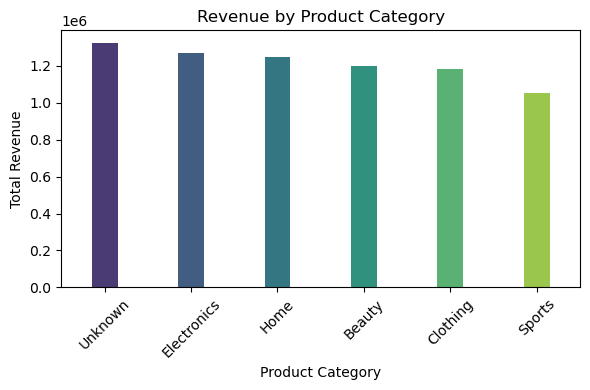

In [20]:
category_revenue = df.groupby('ProductCategory')['Revenue'].sum()
top_category = category_revenue.sort_values(ascending=False)
plt.figure(figsize=(6,4))

sns.barplot(
    x=top_category.index,
    y=top_category.values,
    hue=top_category.index,   # add this
    width=0.3,
    palette="viridis",
    legend=False
)

plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

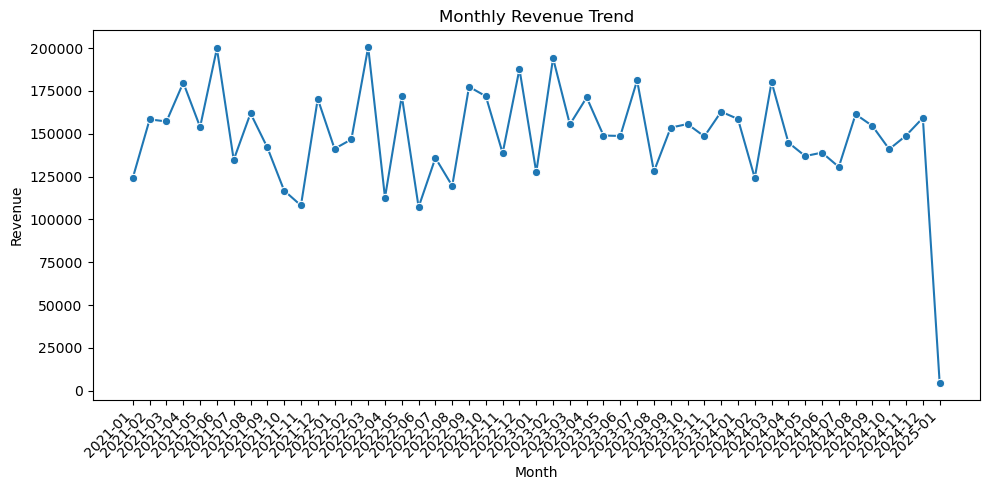

In [21]:
df['Month'] = df['SignupDate'].dt.to_period('M')
monthly_revenue = df.groupby('Month')['Revenue'].sum()
monthly_revenue.index = monthly_revenue.index.astype(str)

plt.figure(figsize=(10,5))

sns.lineplot(x=monthly_revenue.index, y=monthly_revenue.values, marker='o')

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


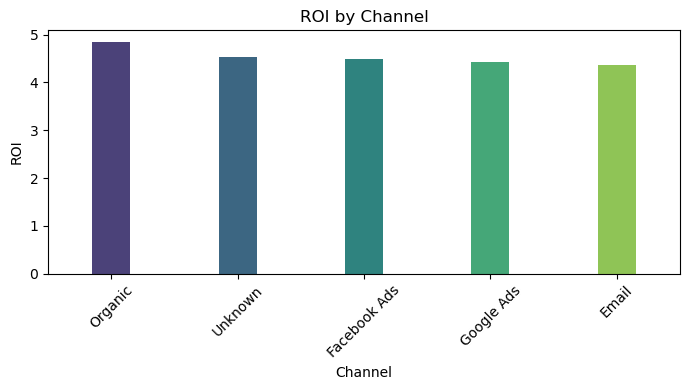

In [22]:
channel_perf = df.groupby('Channel')[['Clicks', 'Impressions', 'AdSpend', 'Revenue']].sum()
channel_perf['CTR'] = channel_perf['Clicks'] / channel_perf['Impressions']
channel_perf['ROI'] = channel_perf['Revenue'] / channel_perf['AdSpend']

channel_perf = channel_perf.sort_values('ROI', ascending=False)
plt.figure(figsize=(7,4))

sns.barplot(
    x=channel_perf.index,
    y=channel_perf['ROI'],
    hue=channel_perf.index,
    width=0.3,
    palette="viridis",
    legend=False
)

plt.title("ROI by Channel")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [23]:
df.head()

,CustomerID,FullName,Age,Gender,Email,Phone,Country,State,City,ZipCode,...,ProductCategory,ProductPrice,DiscountApplied,PaymentMethod,OrderStatus,CustomerSatisfactionScore,SupportTickets,ReturnFlag,IsActiveCustomer,Month
0,US43227,Olivia Garcia,49,Unknown,user930@gmail.com,14987565811.0,USA,Illinois,New York,49576.0,...,Sports,304.63,10.0,PayPal,Completed,2.0,3,0,0,2022-12
1,US74388,Isabella Miller,44,Other,user1162@gmail.com,18391982513.0,USA,Texas,Miami,Unknown,...,Unknown,956.63,30.0,PayPal,Returned,3.0,6,1,1,2021-10
2,US11385,James Miller,44,Unknown,user7412@gmail.com,16408189242.0,USA,NaN,Los Angeles,48282.0,...,Beauty,941.40,0.0,NaN,Pending,4.0,7,1,0,2024-12
3,US15659,Noah Miller,58,Unknown,invalid_email,13354831949.0,USA,NaN,NaN,89333.0,...,Electronics,249.79,10.0,PayPal,Pending,3.0,1,1,0,2022-04
4,US36522,Noah Johnson,24,Male,user140@gmail.com,16792159897.0,USA,California,Los Angeles,83301.0,...,Clothing,376.47,0.0,Credit Card,Pending,3.0,2,1,1,2021-05


In [24]:
df.columns

Index(['CustomerID', 'FullName', 'Age', 'Gender', 'Email', 'Phone', 'Country',
       'State', 'City', 'ZipCode', 'SignupDate', 'LastLoginDate',
       'CampaignName', 'Channel', 'AdSpend', 'Clicks', 'Impressions', 'CTR',
       'ConversionRate', 'LeadsGenerated', 'Conversions', 'Revenue',
       'ProductCategory', 'ProductPrice', 'DiscountApplied', 'PaymentMethod',
       'OrderStatus', 'CustomerSatisfactionScore', 'SupportTickets',
       'ReturnFlag', 'IsActiveCustomer', 'Month'],
      dtype='object')

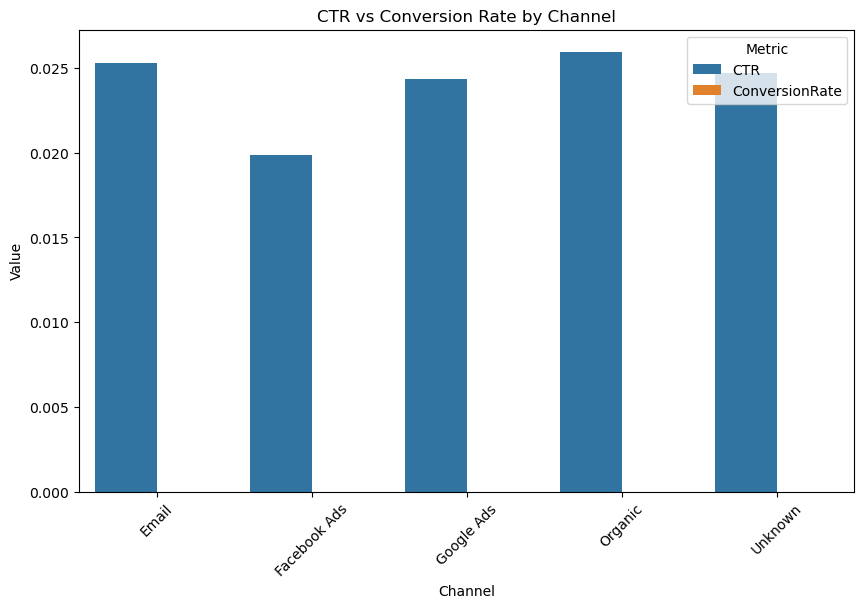

In [25]:
df['CTR'] = df['Clicks'] / df['Impressions']
df['ConversionRate'] = df['Conversions'] / df['Clicks']
comparison = df.groupby('Channel')[['CTR', 'ConversionRate']].mean().reset_index()

comparison_melted = comparison.melt(id_vars='Channel', 
                                    value_vars=['CTR', 'ConversionRate'],
                                    var_name='Metric', 
                                    value_name='Value')

plt.figure(figsize=(10,6))
sns.barplot(data=comparison_melted, x='Channel', y='Value', hue='Metric')

plt.title("CTR vs Conversion Rate by Channel")
plt.xticks(rotation=45)
plt.show()

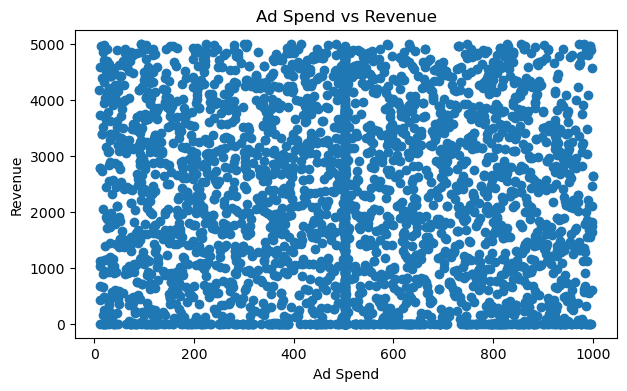

In [27]:
df['ROI'] = (df['Revenue'] - df['AdSpend']) / df['AdSpend']
df['ROI'] = np.where(
    df['AdSpend'] == 0,
    0,
    (df['Revenue'] - df['AdSpend']) / df['AdSpend']
)
plt.figure(figsize=(7,4))
plt.scatter(df['AdSpend'], df['Revenue'])
plt.xlabel('Ad Spend')
plt.ylabel('Revenue')
plt.title('Ad Spend vs Revenue')
plt.show()

In [28]:
df.columns

Index(['CustomerID', 'FullName', 'Age', 'Gender', 'Email', 'Phone', 'Country',
       'State', 'City', 'ZipCode', 'SignupDate', 'LastLoginDate',
       'CampaignName', 'Channel', 'AdSpend', 'Clicks', 'Impressions', 'CTR',
       'ConversionRate', 'LeadsGenerated', 'Conversions', 'Revenue',
       'ProductCategory', 'ProductPrice', 'DiscountApplied', 'PaymentMethod',
       'OrderStatus', 'CustomerSatisfactionScore', 'SupportTickets',
       'ReturnFlag', 'IsActiveCustomer', 'Month', 'ROI'],
      dtype='object')

In [29]:
bins = [0, 18, 25, 35, 50, 100]
labels = ['<18', '18-25', '26-35', '36-50', '50+']

df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)
age_purchase = df.groupby('AgeGroup')['Conversions'].sum()
print(age_purchase)

AgeGroup
<18        755
18-25     6313
26-35     8492
36-50    95967
50+      17405
Name: Conversions, dtype: int64


C:\Users\TLS\AppData\Local\Temp\ipykernel_18920\4133933749.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_purchase = df.groupby('AgeGroup')['Conversions'].sum()


Top Age Group: 36-50


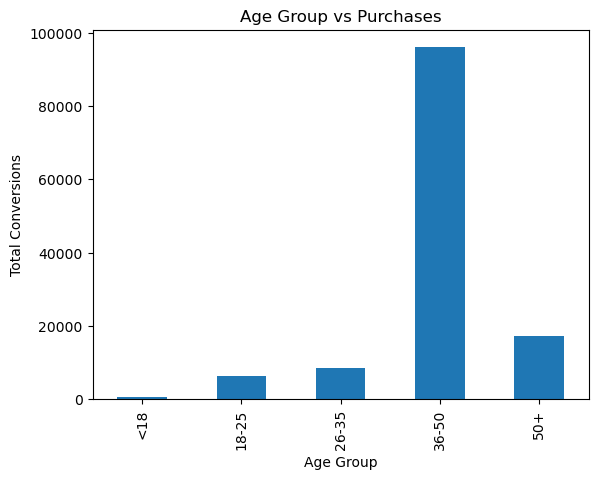

In [30]:
print("Top Age Group:", age_purchase.idxmax())
age_purchase.plot(kind='bar')
plt.title("Age Group vs Purchases")
plt.xlabel("Age Group")
plt.ylabel("Total Conversions")
plt.show()

Gender
Female     24364
Male       27546
Other      24893
Unknown    52129
Name: Conversions, dtype: int64


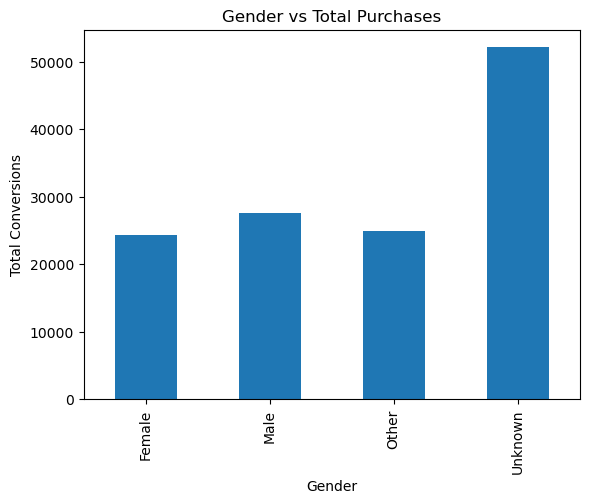

In [31]:
gender_behavior = df.groupby('Gender')['Conversions'].sum()
print(gender_behavior)
gender_behavior.plot(kind='bar')
plt.title("Gender vs Total Purchases")
plt.xlabel("Gender")
plt.ylabel("Total Conversions")
plt.show()

City
New York       553
Los Angeles    551
Chicago        535
Houston        521
Miami          520
Name: count, dtype: int64


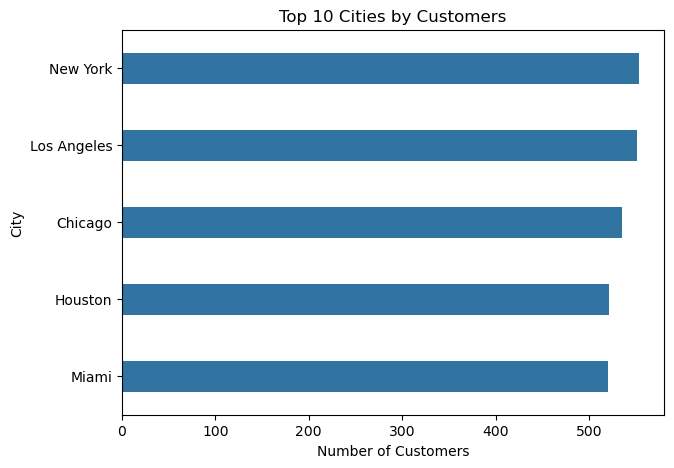

In [32]:
top_cities = df['City'].value_counts().head(10)
print(top_cities)
plt.figure(figsize=(7,5))
sns.barplot(x=top_cities.values, y=top_cities.index,width=0.4)

plt.title("Top 10 Cities by Customers")
plt.xlabel("Number of Customers")
plt.ylabel("City")
plt.show()

Funnel Analysis

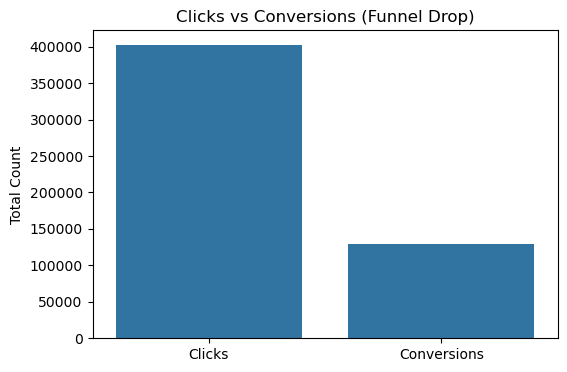

In [34]:
plt.figure(figsize=(6,4))

sns.barplot(data=df[['Clicks','Conversions']].sum().reset_index(),
            x='index', y=0)

plt.title("Clicks vs Conversions (Funnel Drop)")
plt.ylabel("Total Count")
plt.xlabel("")
plt.show()

         Stage       Users  ConversionRate      Drop_%
0  Impressions  32758001.0             NaN         NaN
1       Clicks    402268.0       -0.987720  198.772001
2        Leads    161765.0       -0.597868  159.786759
3  Conversions    128932.0       -0.202967  120.296727

🔥 Weakest stage in funnel: Clicks


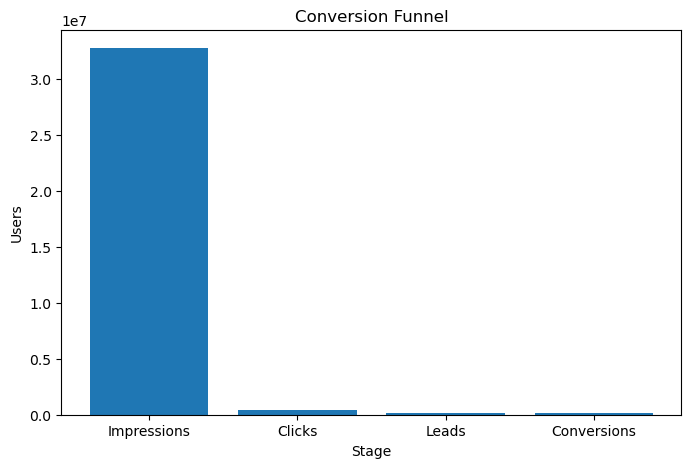

In [73]:


# Step 1: total users at each stage
impressions = df["Impressions"].sum()
clicks = df["Clicks"].sum()
leads = df["LeadsGenerated"].sum()
conversions = df["Conversions"].sum()

# Step 2: funnel dataframe
funnel_df = pd.DataFrame({
    "Stage": ["Impressions", "Clicks", "Leads", "Conversions"],
    "Users": [impressions, clicks, leads, conversions]
})

# Step 3: conversion rate (next step)
funnel_df["ConversionRate"] = funnel_df["Users"].pct_change()

# Step 4: drop percentage
funnel_df["Drop_%"] = (1 - funnel_df["ConversionRate"]) * 100

print(funnel_df)

# Step 5: weakest stage find karo
weak_stage = funnel_df.loc[funnel_df["Drop_%"].idxmax(), "Stage"]

print("\n🔥 Weakest stage in funnel:", weak_stage)
plt.figure(figsize=(8,5))
plt.bar(funnel_df["Stage"], funnel_df["Users"])
plt.title("Conversion Funnel")
plt.xlabel("Stage")
plt.ylabel("Users")
plt.show()

Sales Behavior

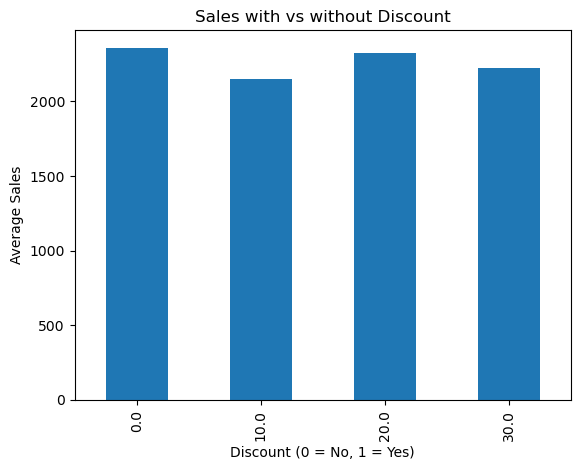

In [84]:
df.groupby('DiscountApplied')['Revenue'].mean().plot(kind='bar')
plt.title('Sales with vs without Discount')
plt.xlabel('Discount (0 = No, 1 = Yes)')
plt.ylabel('Average Sales')
plt.show()

In [80]:
df.columns

Index(['CustomerID', 'FullName', 'Age', 'Gender', 'Email', 'Phone', 'Country',
       'State', 'City', 'ZipCode', 'SignupDate', 'LastLoginDate',
       'CampaignName', 'Channel', 'AdSpend', 'Clicks', 'Impressions', 'CTR',
       'ConversionRate', 'LeadsGenerated', 'Conversions', 'Revenue',
       'ProductCategory', 'ProductPrice', 'DiscountApplied', 'PaymentMethod',
       'OrderStatus', 'CustomerSatisfactionScore', 'SupportTickets',
       'ReturnFlag', 'IsActiveCustomer', 'Month', 'ROI', 'AgeGroup'],
      dtype='object')